In [18]:
import os
import sys

project_root = '/home/jovyan/project_10x'

sys.path.append(os.path.join(project_root, 'src'))

from utils import *
from sentiment_extraction_MB_10q import *

import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
clean_mem()

In [4]:
sys.version

'3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:43:55) [GCC 13.3.0]'

# Model - ModernBERT

In [8]:
model_id = "/home/jovyan/models-2/ModernBERT-large"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_id,
#                                           max_length=length,
                                          padding=True,
                                          truncation=True,
                                          cache_dir="hf_cache")
if not tokenizer.pad_token:
    print("Adding pad token")
    tokenizer.pad_token = tokenizer.eos_token
    
tokenizer.padding_side = "left"

model = AutoModelForMaskedLM.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, cache_dir="hf_cache"
).to(device)

config = AutoConfig.from_pretrained(model_id)
length = config.max_position_embeddings
length

8192

In [11]:
model.name = 'ModernBERT'

In [12]:
def get_prompt(item_text: str, ending: str) -> str:
    return item_text + "\n\n" + ending 

## 10 Qs

In [13]:
# import zipfile

# with zipfile.ZipFile('/home/jovyan/datavol-2/files_10qs.zip', 'r') as zip_ref:
#     zip_ref.extractall('/home/jovyan/datavol-2/')

In [14]:
report_path = '/home/jovyan/datavol-2/'

reports = pd.read_csv(os.path.join(report_path, '10q_filtered.tsv.gz'), sep='\t')
reports = reports[['CIK', 'FILING_DATE', 'ACC_NUM']]
reports['CIK'] = reports['CIK'].astype(str)
reports['FILING_DATE'] = reports['FILING_DATE'].astype(str)
reports['ACC_NUM'] = reports['ACC_NUM'].astype(str)
# reports

In [15]:
reports['FILING_DATE'].astype(str).str[:4].value_counts().sort_index()

FILING_DATE
2003     4634
2004     4740
2005     4928
2006     5184
2007     5568
2008     7163
2009     7569
2010     7852
2011     8305
2012     8726
2013     9003
2014     9498
2015    10011
2016    10445
2017    10847
2018    11436
2019    12145
2020    12059
2021    14745
2022    16335
2023    15120
Name: count, dtype: int64

In [15]:
res_df = reports[reports['FILING_DATE'].astype(str).str[:4] > '2003'].copy().reset_index(drop=True)
res_df = res_df.drop_duplicates().reset_index(drop=True)

res_df.shape, res_df.drop_duplicates().shape

((191679, 3), (191679, 3))

In [16]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191679 entries, 0 to 191678
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   CIK          191679 non-null  object
 1   FILING_DATE  191679 non-null  object
 2   ACC_NUM      191679 non-null  object
dtypes: object(3)
memory usage: 4.4+ MB


In [18]:
res_df

,CIK,FILING_DATE,ACC_NUM
0,1750,20040114,0001104659-04-000842
1,1750,20041001,0001104659-04-029310
2,1750,20050105,0001104659-05-000400
3,1750,20050406,0001104659-05-015316
4,1750,20051005,0001104659-05-047317
...,...,...,...
191674,1980088,20231207,0001628280-23-041085
191675,1981792,20231106,0001628280-23-037021
191676,1983736,20231113,0001493152-23-040360
191677,1984060,20231031,0000950170-23-056532


In [20]:
res_df.to_csv('/home/jovyan/datavol-2/res_df_10qs_2004_2023.csv', index=True)

In [19]:
!ls -la /home/jovyan/datavol-2/files_10qs | head -n 5

total 30624836
drwxrwsr-x  2 jovyan 1337 14020608 Mar  4 13:33 .
drwxrwsr-x 13 root   1337     4096 Mar  5 10:12 ..
-rw-rw-r--  1 jovyan 1337    82270 Mar  4 13:33 20040102_10-Q_edgar_data_909832_0001193125-04-000178.txt
-rw-rw-r--  1 jovyan 1337   110756 Mar  4 13:30 20040105_10-Q_edgar_data_23217_0001104659-04-000051.txt
ls: write error: Broken pipe


In [19]:
items_path = '/home/jovyan/datavol-2/files_10qs'

dataset = Dataset10q(res_df, items_path)
len(dataset)

191679

In [20]:
ending = "In one word, we are [MASK] regarding the future growth of our company."
inputs = tokenizer(ending, return_tensors="pt", padding=True)
inputs['input_ids'].shape

torch.Size([1, 17])

### Number of symbols

In [17]:
q99 = 736659
q95 = 377225

chunk_size = length - 100 # for the ending
chunk_size

8092

In [18]:
splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(tokenizer=tokenizer,
                                                                     chunk_size=chunk_size,
                                                                     chunk_overlap=240)

## Growth Sentiment Extraction

### In one word, we are [MASK] regarding the future growth of our company

In [19]:
ending = "In one word, we are [MASK] regarding the future growth of our company."

In [23]:
idx = 23

_, item_text = dataset[idx]
date = res_df.iloc[idx].FILING_DATE

item_text = item_text[:20_000]

print(f"{idx} length: {len(item_text)}, date: {date}")

In [41]:
prompt = get_prompt(item_text, ending)
probs = get_model_output(prompt, model, device)
probs

input has torch.Size([1, 8192]) tokens


{' confident': 0.326171875,
 ' optimistic': 0.224609375,
 ' uncertain': 0.1201171875,
 ' concerned': 0.050048828125,
 ' excited': 0.0303955078125,
 ' cautious': 0.0208740234375,
 ' certain': 0.0196533203125,
 ' unsure': 0.0162353515625,
 ' hopeful': 0.010498046875,
 ' serious': 0.00677490234375,
 ' enthusiastic': 0.00677490234375,
 ' positive': 0.005615234375,
 ' doubtful': 0.005615234375,
 ' nervous': 0.004669189453125,
 ' committed': 0.00439453125,
 ' anxious': 0.004119873046875,
 ' skeptical': 0.003631591796875,
 ' worried': 0.003631591796875,
 ' conservative': 0.003204345703125,
 ' convinced': 0.0028228759765625}

In [20]:
clean_mem()

In [21]:
@dataclass(frozen=True)
class Prompt_Strategy:
    name: str
    verbalizer: dict
    prompt: Callable
    top_p: float = 0.9

sentiment_verb = {
    "positive": set(['optimistic', 'confident', 'positive', 'encouraged', 'excited',
                     'enthusiastic', 'hopeful', 'pleased', 'encouraging', 'ambitious',
                     'favorable', 'assured', 'strong', 'good', 'excellent', 'outstanding', 
                     'healthy', 'awesome', 'great', 'fantastic', 'stable',
                     'perfect', 'solid', 'profitable', 'impressive', 'reliable',
                     'thriving', 'optimistic', 'sustainable',
                     'exceptional', 'promising', 'bright', 'attractive'
                     ]),
    
    "negative": set(['cautious', 'concerned', 'pessimistic', 'negative',
                     'uncomfortable', 'uncertain', 'unsure',
                     'skeptical', 'worried', 'worrying', 'discouraged', 
                     'confused', 'doubtful', 'unsatisfied', 'disappointed',
                     'bad', 'poor', 'terrible', 'risky', 'weak', 'dependent',
                     'unstable', 'unhealthy', 'questionable', 'suffering', 'stressed',
                     'unsustainable', 'awful', 'vulnerable',
                     'mediocre', 'horrible', 'precarious', 'declining', 'worsening',
                     'difficult', 'limited', 'challenged', 'disappointed', 'discouraged',
                     'frustrated', 'dissatisfied', 'worried', 'anxious', 'nervous', 'uneasy',
                     'doubtful', 'skeptical', 'apprehensive',
                    ])
}


sentiment_strategy = Prompt_Strategy('sentiment', sentiment_verb, get_prompt)

len(sentiment_verb['positive']), len(sentiment_verb['negative'])

(32, 43)

In [22]:
clean_mem()

In [23]:
ending = "In one word, we are [MASK] regarding the future growth of our company."

In [24]:
results = []

df = pd.read_csv('/home/jovyan/datavol-2/sentiments/growth_MB_10qs/results_20260319_182658_1000_reports.csv')

In [25]:
# df = df.drop('index', axis=1)
# df['level_0'] = df['level_0'].astype(int)
df = df.set_index('index')
results.append(df)
# df

In [27]:
max_processed_idx = int(max([df.index.max() for df in results if not df.empty]))
max_processed_idx

179054

In [28]:
batch_size = 2
items_path = '/home/jovyan/datavol-2/files_10qs'

dataset = Dataset10q(res_df, items_path)
print('dataset', len(dataset))

dataset 191679


In [29]:
sampler = IndexBasedSampler(dataset, start_idx=max_processed_idx)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    sampler=sampler,
    collate_fn=split_collator,
    shuffle=False
)

print('dataloader', len(dataloader))

dataloader 6313


In [ ]:
stats_sent = gather_stats(sentiment_strategy, results=results, tokenizer=tokenizer, model=model,
                          data=dataloader, ending=ending, verbose=True, text_length=q95, 
                          save_path="/home/jovyan/datavol-2/sentiments/growth_MB_10qs/",
                          save_interval=1000, resume=True, max_retries=3, device=device)

Resuming from index: 179054


  1%|          | 56/6313 [11:56<17:09:08,  9.87s/it]

In [ ]:
clean_mem()

In [ ]:
time.sleep(60)
clean_mem()
torch.cuda.empty_cache()
time.sleep(60)

In [ ]:
stats_sent.to_csv('/home/jovyan/datavol-2/sentiments/growth_MB_10qs/results_growth_MB_10qs_2004_2023.csv')

In [3]:
stats_sent = pd.read_csv('/home/jovyan/datavol-2/sentiments/growth_MB_10qs/results_growth_MB_10qs_2004_2023.csv')

<Axes: >

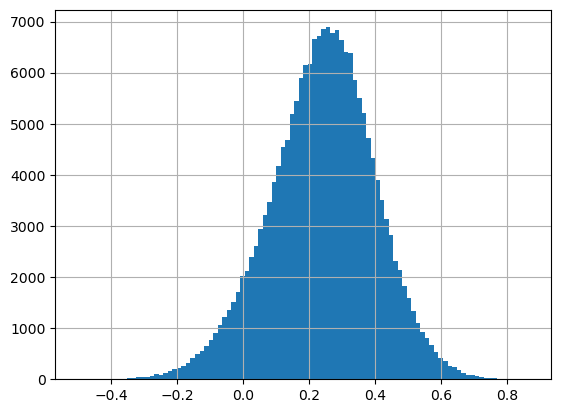

In [4]:
stats_sent['polarity'].hist(bins=100)